<p align="center"><img src="https://drive.google.com/thumbnail?id=1droFz5VphApD8FGVPjyXqIFGBGaJmhxO&sz=w600" width="30%">&nbsp;&nbsp;<img src="https://drive.google.com/thumbnail?id=14yWNOODEq5cv8qnuNgvA-DQpiQl6bwWs&sz=w600" width="35%">&nbsp;&nbsp;<img src="https://drive.google.com/thumbnail?id=1yy6jjksbi0hcIkbFpxxyeKJS2B4Dk4x-&sz=w600" width="20%"></p>

<h1 align="center"> <b>Modelos de Predicción y Aprendizaje Automático Informado por la Física Aplicado a Sistemas Energéticos</b></h1>

<h3 align="center">
 <b>Proyecto End-to-End:  <em>Análisis Exploratorio + Ingeniería de Características + Regresión Lineal</em></b>
</h3>

A partir de un dataset de demanda horaria de bicicletas en Seúl, el estudiante implementará un pipeline completo de Machine Learning siguiendo la metodología CRISP-DM: exploración de datos, procesamiento, ingeniería de características y entrenamiento de un
modelo de regresión lineal, comprendiendo el rol de cada etapa en el resultado final.

**Objetivos:**
- Aplicar correctamente la partición train/test antes de cualquier análisis, reconociendo el concepto de *data leakage* y sus consecuencias sobre del modelo.
- Implementar técnicas de ingeniería de características (encoding cíclico, transformaciones logarítmicas e interacciones).
- Interpretar los resultados de un modelo de regresión lineal a través del análisis de residuos y los coeficientes estandarizados de cada variable.
---

## 1. Carga de Librerías


In [1]:
!pip install ucimlrepo #Libreria para descargar la base de datos

In [16]:
# Carga de datos
from ucimlrepo import fetch_ucirepo

# Manipulación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de procesamiento de datos y aprendizaje automático.
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración de gráficas.
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


## 2. Carga de datos e Inspección Inicial

Cargamos el dataset y hacemos una primera inspección para entender su estructura,
tipos de variables y posibles problemas de calidad.


In [17]:
# Cargar la base de datos
seoul_bike_sharing_demand = fetch_ucirepo(id=560)

# Variables predictoras y variable objetivo
X = seoul_bike_sharing_demand.data.features
y = seoul_bike_sharing_demand.data.targets

# Unir todo en un único DataFrame
df = pd.concat([X, y], axis=1)

# Visualizar las primeras filas
df.head()

# Se elimina la variable date puesto que no aporta información adicional a la
# presentada por las variables: hour, seasons, holiday and functioning day.
df = df.drop(columns=['Date'])

In [18]:
# Resumen de tipos y valores nulos
print("=== Tipos de datos y valores nulos ===\n")
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info.to_string())


=== Tipos de datos y valores nulos ===

                         dtype  nulos  pct_nulos
Rented Bike Count        int64      0        0.0
Hour                     int64      0        0.0
Temperature            float64      0        0.0
Humidity                 int64      0        0.0
Wind speed             float64      0        0.0
Visibility               int64      0        0.0
Dew point temperature  float64      0        0.0
Solar Radiation        float64      0        0.0
Rainfall               float64      0        0.0
Snowfall               float64      0        0.0
Seasons                 object      0        0.0
Holiday                 object      0        0.0
Functioning Day         object      0        0.0


In [19]:
# Estadísticos descriptivos de las variables numéricas
df.describe().round(2)


,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall
count,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,704.60,11.50,12.88,58.23,1.72,1436.83,4.07,0.57,0.15,0.08
std,645.00,6.92,11.94,20.36,1.04,608.30,13.06,0.87,1.13,0.44
min,0.00,0.00,-17.80,0.00,0.00,27.00,-30.60,0.00,0.00,0.00
25%,191.00,5.75,3.50,42.00,0.90,940.00,-4.70,0.00,0.00,0.00
50%,504.50,11.50,13.70,57.00,1.50,1698.00,5.10,0.01,0.00,0.00
75%,1065.25,17.25,22.50,74.00,2.30,2000.00,14.80,0.93,0.00,0.00
max,3556.00,23.00,39.40,98.00,7.40,2000.00,27.20,3.52,35.00,8.80


## 3. Partición Train / Test — ¡PRIMERO que cualquier análisis!

Antes de iniciar el análisis exploratorio, es necesario dividir la base de datos en dos subconjuntos:

- **Conjunto de entrenamiento (`train`)**: se utiliza para explorar los datos, calcular estadísticas, ajustar transformaciones y entrenar el modelo.
- **Conjunto de prueba (`test`)**: se reserva para evaluar el desempeño final del modelo con observaciones que no participaron en el proceso de entrenamiento.
- **Regla de oro:** separar los datos **antes** de explorar, imputar o transformar las variables.
- Si analizamos la base de datos completa antes de realizar la división, podemos utilizar indirectamente información del conjunto de prueba durante el entrenamiento.
- Este problema se conoce como **fuga de información** o **data leakage**.
- A partir de este punto, todas las decisiones relacionadas con la preparación de los datos deben tomarse utilizando **únicamente el conjunto de entrenamiento**.


In [20]:
# Separamos features (X) y variable objetivo (y)
X = df.drop(columns=['Rented Bike Count'])
y = df['Rented Bike Count']

# División aleatoria, se pero fija random_state=42 para garantizar reproducibilidad.
# Se realiza una partición 80/20. 80% para el conjunto de train y 20% para test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Entrenamiento : {X_train.shape[0]:,} muestras  ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Prueba        : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"\nDistribución del target (y_train):")
print(y_train.describe().round(1))


Entrenamiento : 7,008 muestras  (80%)
Prueba        : 1,752 muestras  (20%)

Distribución del target (y_train):
count    7008.0
mean      704.8
std       644.9
min         0.0
25%       191.0
50%       507.0
75%      1065.2
max      3418.0
Name: Rented Bike Count, dtype: float64


## 4. Análisis Exploratorio de Datos (EDA)

Todo el EDA se realiza **exclusivamente sobre el conjunto de entrenamiento**.


### 4.1 Distribución de la variable objetivo


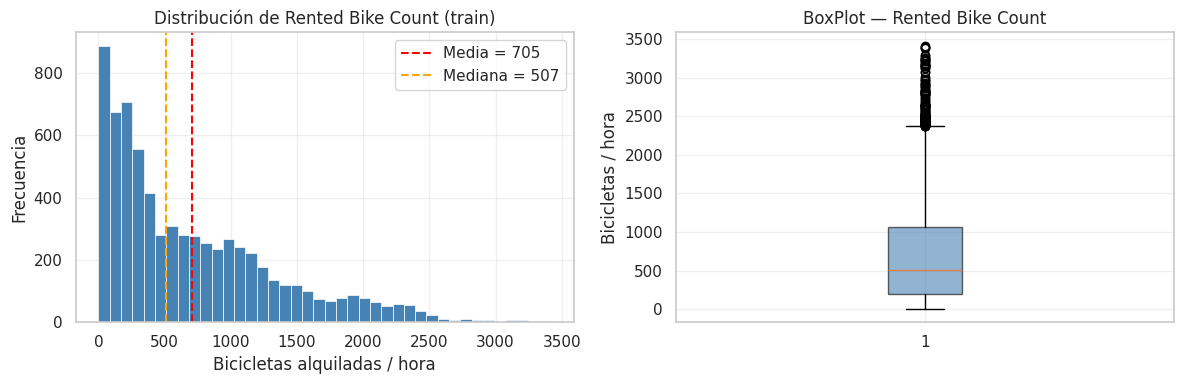

Skewness : 1.154  (|>1| indica asimetría importante)
Kurtosis : 0.857


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(y_train, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución de Rented Bike Count (train)')
axes[0].set_xlabel('Bicicletas alquiladas / hora')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(y_train.mean(), color='red', linestyle='--', label=f'Media = {y_train.mean():.0f}')
axes[0].axvline(y_train.median(), color='orange', linestyle='--', label=f'Mediana = {y_train.median():.0f}')
axes[0].legend()

# BoxPlot
axes[1].boxplot(y_train, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('BoxPlot — Rented Bike Count')
axes[1].set_ylabel('Bicicletas / hora')

plt.tight_layout()
plt.show()

print(f"Skewness : {y_train.skew():.3f}  (|>1| indica asimetría importante)")
print(f"Kurtosis : {y_train.kurt():.3f}")


### 4.2 Patrones horarios y de temperatura


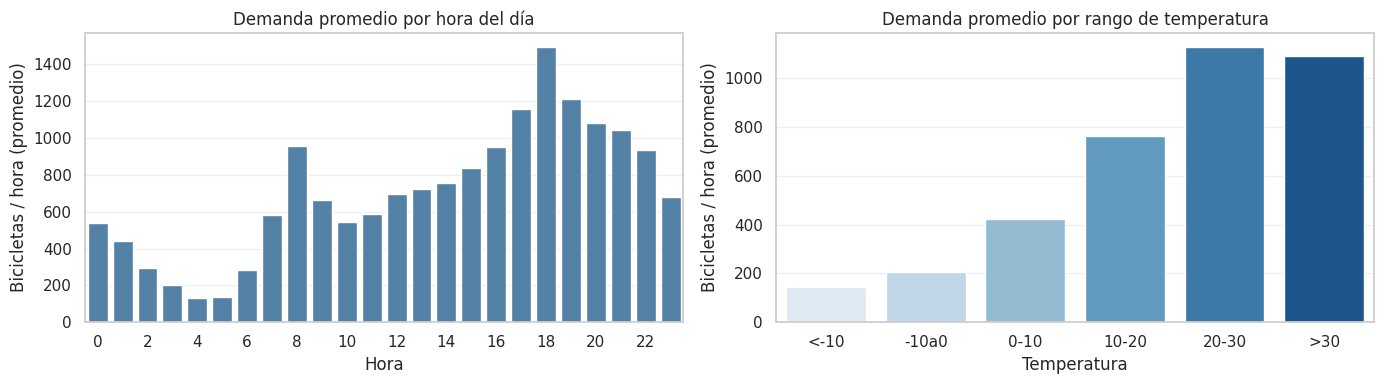

In [23]:
# Unimos X_train con y_train para análisis
df_train = X_train.copy()
df_train['Rented Bike Count'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Demanda promedio por hora
hourly = df_train.groupby('Hour')['Rented Bike Count'].mean()
hourly_df = hourly.reset_index()
# Usar un solo color para todas las barras
sns.barplot(x='Hour', y='Rented Bike Count', data=hourly_df, ax=axes[0],
            color='steelblue') # Un color único
axes[0].set_title('Demanda promedio por hora del día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Bicicletas / hora (promedio)')
axes[0].set_xticks(range(0, 24, 2))

# Demanda promedio por rango de temperatura
bins   = [-25, -10, 0, 10, 20, 30, 55]
labels = ['<-10', '-10a0', '0-10', '10-20', '20-30', '>30']
df_train['temp_bin'] = pd.cut(df_train['Temperature'], bins=bins, labels=labels)
temp_avg = df_train.groupby('temp_bin', observed=True)['Rented Bike Count'].mean()
temp_avg_df = temp_avg.reset_index()
# Convertir la paleta a una lista explícitamente y usar 'hue' para las categorías
palette_temp = sns.color_palette('Blues', n_colors=len(temp_avg_df))
sns.barplot(x='temp_bin', y='Rented Bike Count', data=temp_avg_df, ax=axes[1],
            hue='temp_bin', palette=palette_temp, dodge=False, legend=False)
axes[1].set_title('Demanda promedio por rango de temperatura')
axes[1].set_xlabel('Temperatura')
axes[1].set_ylabel('Bicicletas / hora (promedio)')

plt.tight_layout()
plt.show()

### 4.3 Histogramas de las variables numéricas

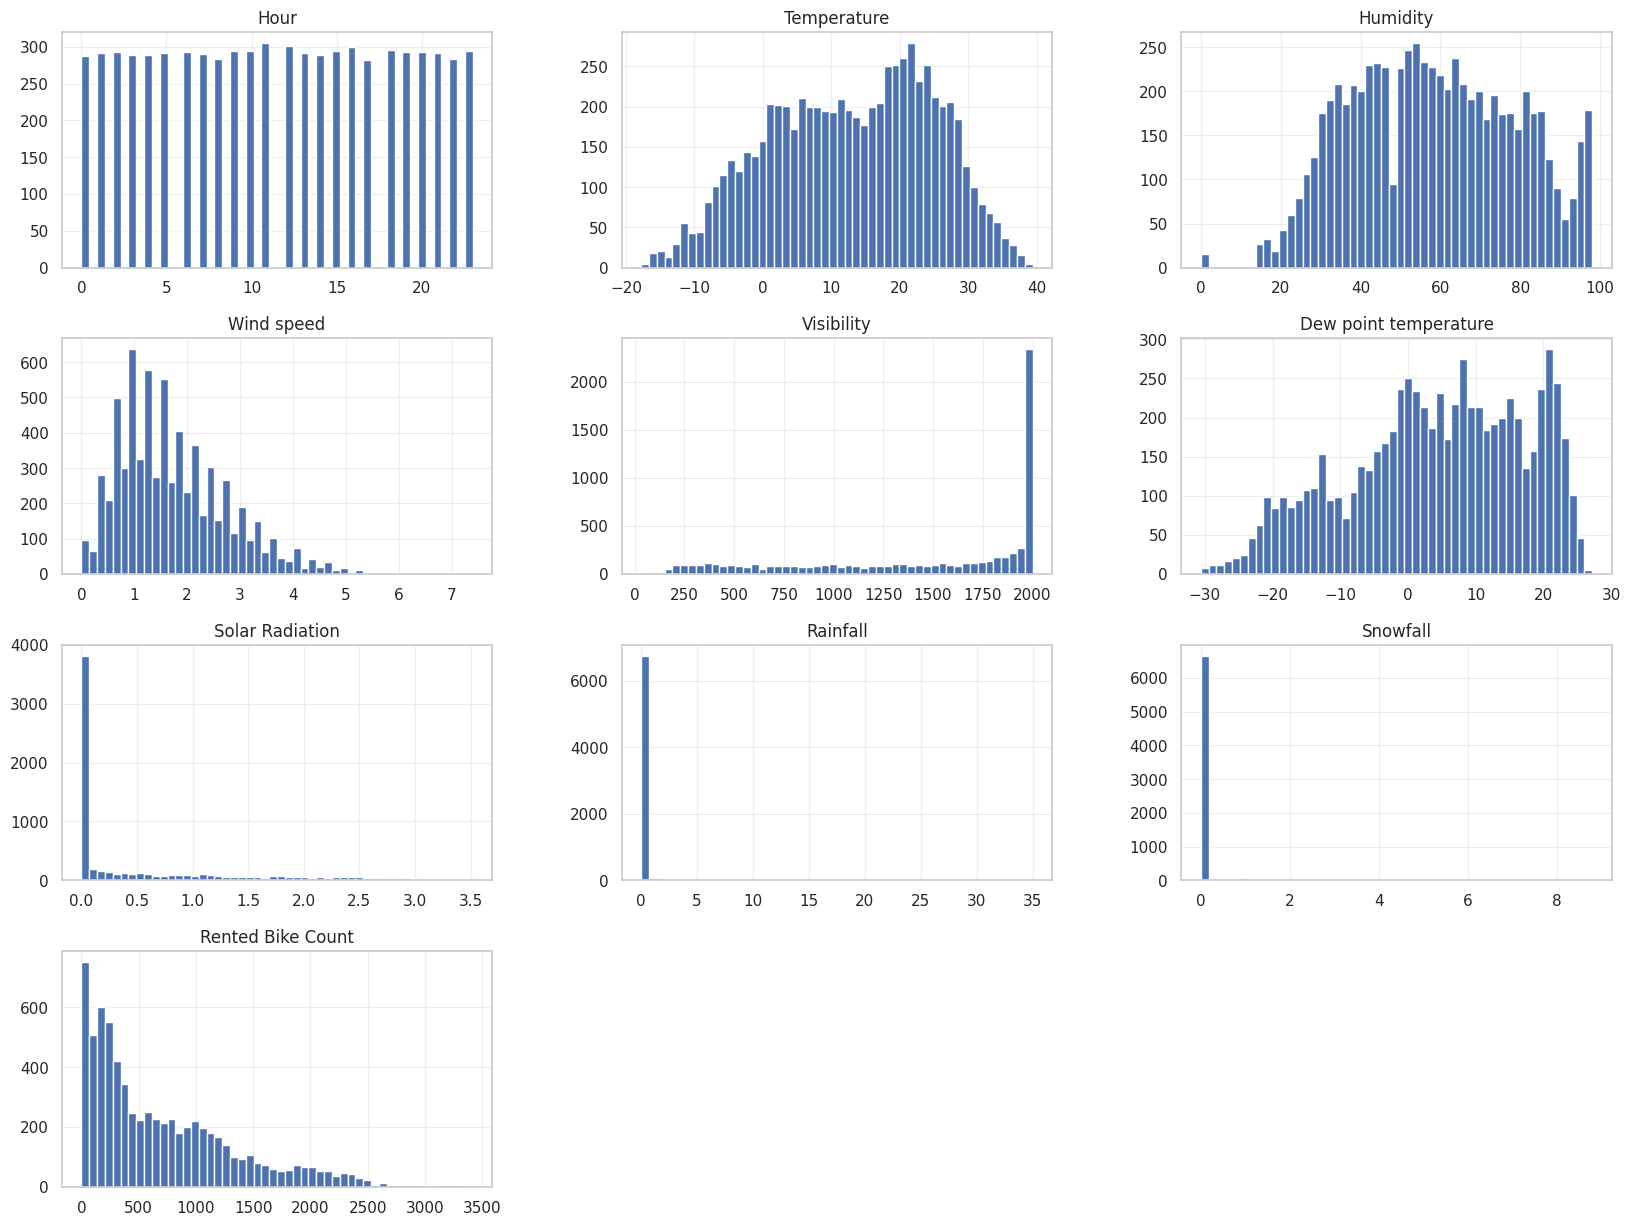

In [24]:
df_train.hist(bins=50, figsize=(20,15))
plt.show()

Algunas observaciones a partir de los histogramas son las siguientes:

1. Los valores de las variables `Rainfall`, `Snowfall`, `Solar Radiation` y `Visibility` se concentran en uno de los extremos de los gráficos. Esto puede indicar que varias observaciones contienen valores atípicos. Una alternativa consiste en eliminar estos valores atípicos o agrupar los datos en un número reducido de intervalos discretos.

2. Tanto `Rented Bike Count` como `Wind Speed` presentan una. Esto significa que la cola derecha de la distribución es más larga y que, generalmente, la media es mayor que la mediana. Algunos algoritmos de aprendizaje automático pueden tener mayor dificultad para identificar patrones cuando las variables presentan este tipo de distribución.

3. Una alternativa consiste en transformar estas variables mediante $\log(x)$ o $\sqrt{x}$, con el propósito de obtener distribuciones más cercanas a una forma de campana.

#### Actividad 1

1. Calcule la media y la mediana de las variables `Rented Bike Count` y `Wind Speed`. Verifique que, en ambos casos, la media sea mayor que la mediana.

2. ¿Cómo cambiarían los histogramas de `Rented Bike Count` y `Wind Speed` si se transformaran sus valores mediante $\sqrt{x}$?

**Nota** Genere una copia de los datos para resolver esta actividad.

In [ ]:
# Presente su respuesta en este espacio

### 4.4 Gráficas de dispersión

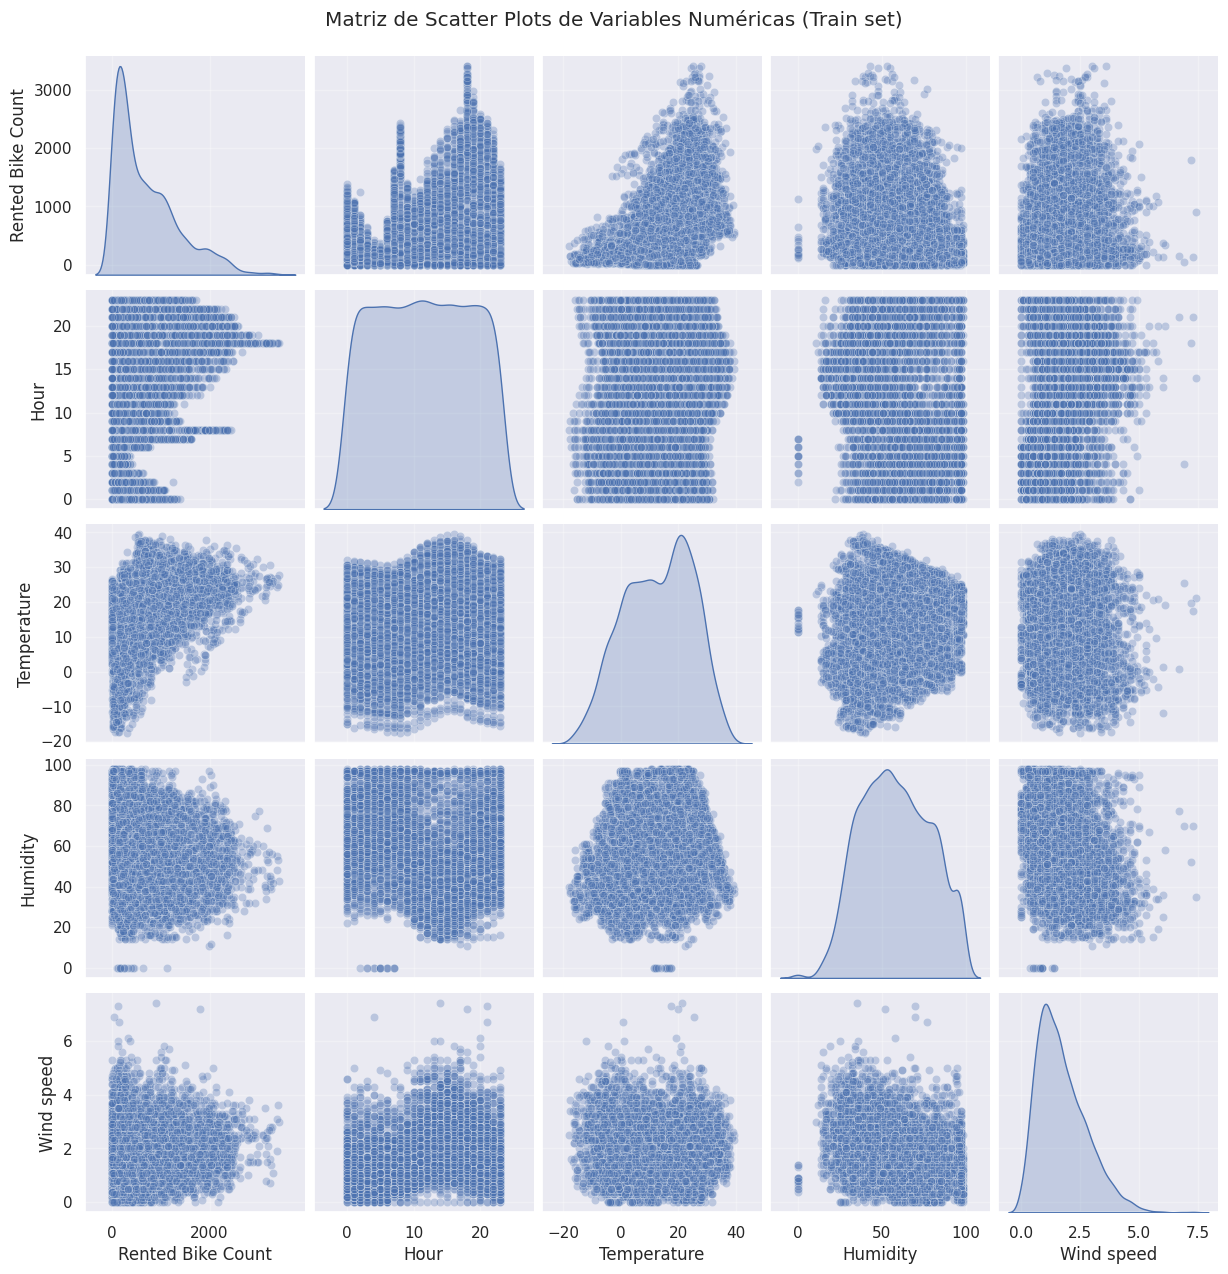

In [25]:
df_plot = df_train[['Rented Bike Count', 'Hour', 'Temperature', 'Humidity', 'Wind speed']]

sns.set_style('darkgrid') # Apply a different seaborn style for this plot
sns.pairplot(df_plot, diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Matriz de Scatter Plots de Variables Numéricas (Train set)', y=1.02)
plt.show()
sns.set_theme(style='whitegrid') # Reset to the default theme used in the notebook

### 4.5 Matriz de correlación


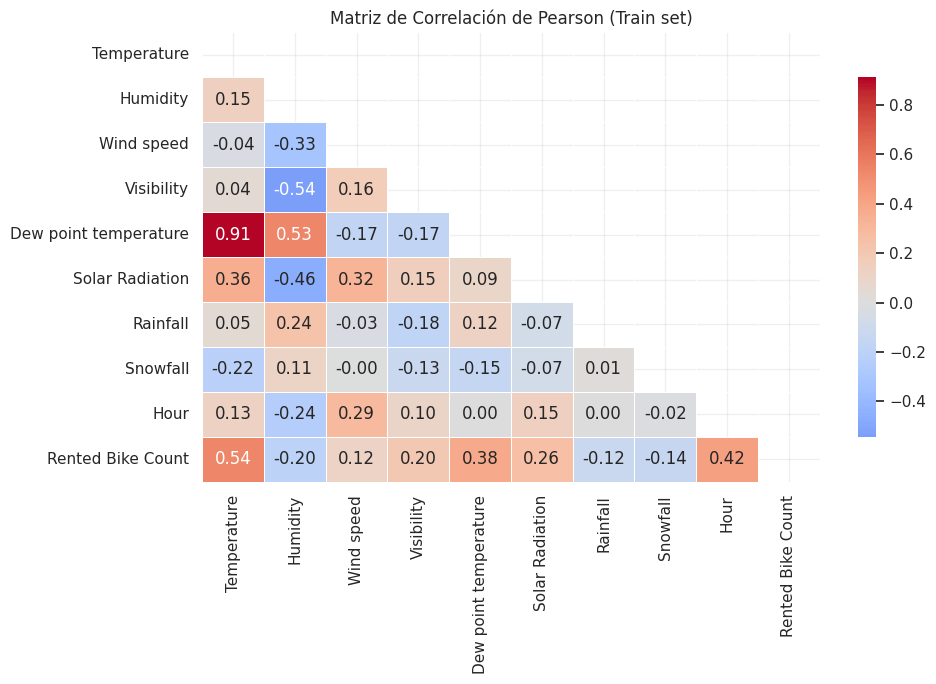


Correlación con el target (orden descendente):
Temperature              0.537088
Hour                     0.418294
Dew point temperature    0.377737
Solar Radiation          0.258930
Visibility               0.204672
Wind speed               0.121388
Rainfall                -0.123586
Snowfall                -0.141440
Humidity                -0.202004


In [27]:
# Correlación de Pearson entre variables numéricas y el target — solo sobre train
num_cols = ['Temperature', 'Humidity', 'Wind speed', 'Visibility',
            'Dew point temperature', 'Solar Radiation',
            'Rainfall', 'Snowfall', 'Hour', 'Rented Bike Count']

corr = df_train[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.set_theme(style='whitegrid')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación de Pearson (Train set)')
plt.tight_layout()
plt.show()
sns.set_theme(style='whitegrid')
print("\nCorrelación con el target (orden descendente):")
print(corr['Rented Bike Count'].drop('Rented Bike Count').sort_values(ascending=False).to_string())

#### Actividad 2

1. Determine la correlación de las variables `Rented Bike Count` y `Wind speed` si se transforman usando $\sqrt{x}$ o $\log(x)$.

In [ ]:
# Presente su respuesta en este espacio

## 5. Procesamiento de Datos

### 5.1 Imputación de valores faltantes

Si bien esta base de datos no presenta datos nulos. A modo de ejemplo calculamos los estadísticos de imputación **solo sobre train** y luego los aplicamos al test.


**Nota** Genere una copia de los datos para resolver esta actividad.

In [40]:
cols_nulas = ['Temperature', 'Wind speed']

print("Nulos ANTES de imputar:")
print(X_train[cols_nulas].isnull().sum().to_string())

# fit_transform en train → aprende la mediana del train
imputer = SimpleImputer(strategy='median')
X_train[cols_nulas] = imputer.fit_transform(X_train[cols_nulas])

# transform en test → aplica la MISMA mediana aprendida (no recalcula)
X_test[cols_nulas]  = imputer.transform(X_test[cols_nulas])

print("\nMedianas aprendidas del train:")
for col, med in zip(cols_nulas, imputer.statistics_):
    print(f"  {col:<28} → {med:.2f}")

print(f"\nNulos en X_train después: {X_train.isnull().sum().sum()}")
print(f"Nulos en X_test después:  {X_test.isnull().sum().sum()}")


Nulos ANTES de imputar:
Temperature    0
Wind speed     0

Medianas aprendidas del train:
  Temperature                  → 13.80
  Wind speed                   → 1.50

Nulos en X_train después: 0
Nulos en X_test después:  0


### 5.2 Codificación de la variable categórica `Seasons` `Holiday` y `Functioning Day`

Usamos **One-Hot Encoding** con `drop_first=True` para evitar colinealidad perfecta.


In [41]:
X_train = pd.get_dummies(X_train, columns=['Seasons', 'Holiday', 'Functioning Day'], prefix=['Season', 'Holiday', 'Functioning_Day'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['Seasons', 'Holiday', 'Functioning Day'], prefix=['Season', 'Holiday', 'Functioning_Day'], drop_first=True)

# Asegurar que test tenga las mismas columnas que train (puede faltar alguna categoría)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Columnas después del encoding:")
print(X_train.columns.tolist())
print(f"\nShape X_train: {X_train.shape}")

Columnas después del encoding:
['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']

Shape X_train: (7008, 14)



## 6. Ingeniería de Características (Feature Engineering)

Esta es una de las etapas más importantes del proyecto. Creamos nuevas variables a partir de las existentes para capturar patrones que la regresión lineal no puede detectar directamente.

Aplicamos la siguiente técnica:

| Técnica | Variables afectadas | Motivación |
|---|---|---|
| **Encoding cíclico** (sin/cos) | `Hour` | La hora 23 y la 0 son vecinas, no opuestas |


### 6.1 Encoding cíclico de la hora del día

La hora del día es una variable **cíclica**: la hora 23 está más cerca de la 0
que de la 12. Si la usamos como número entero, el modelo pensará que 0 y 23
son muy distintas. La solución es proyectarla en un círculo usando seno y coseno.

$$\text{hour_sin} = \sin\left(\frac{2\pi \cdot \text{Hour}}{24}\right), \quad
\text{hour_cos} = \cos\left(\frac{2\pi \cdot \text{Hour}}{24}\right)$$


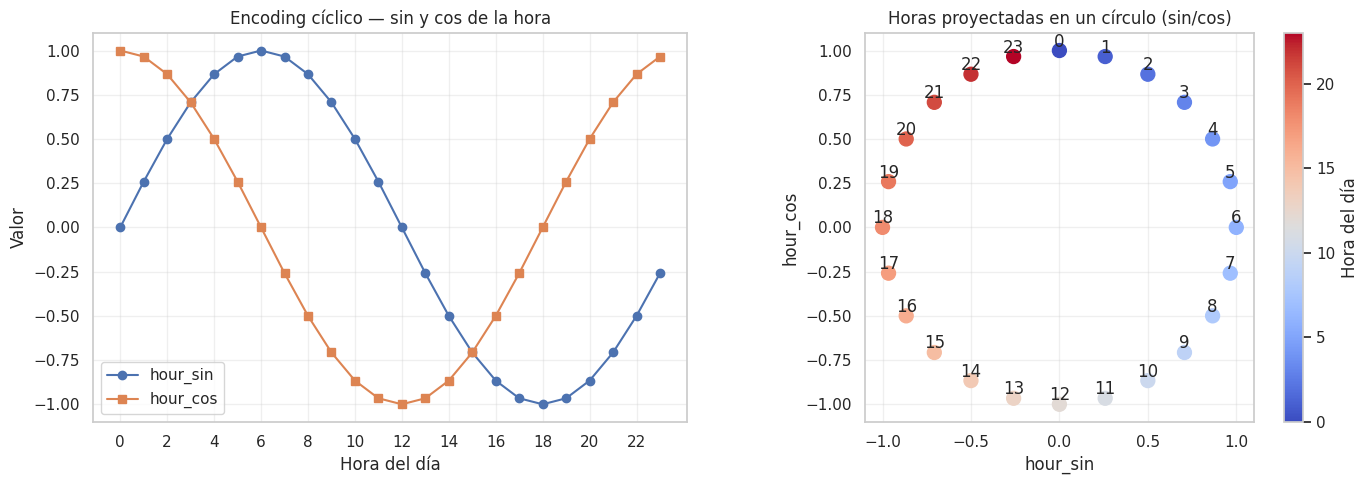

La hora 0 y la hora 23 quedan muy cerca en el espacio sin/cos


In [42]:
def add_hour_cyclic(df):
    """Proyecta Hour en coordenadas seno/coseno y elimina la columna original."""
    df = df.copy()
    df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
    df = df.drop(columns=['Hour'])
    return df

# Visualizamos el encoding cíclico
horas = np.arange(24)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns_colors = sns.color_palette('deep')
axes[0].plot(horas, np.sin(2*np.pi*horas/24), color=sns_colors[0], label='hour_sin', marker='o')
axes[0].plot(horas, np.cos(2*np.pi*horas/24), color=sns_colors[1],    label='hour_cos', marker='s')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Valor')
axes[0].set_title('Encoding cíclico — sin y cos de la hora')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()


scatter = axes[1].scatter(np.sin(2*np.pi*horas/24), np.cos(2*np.pi*horas/24),
                c=horas, cmap='coolwarm', s=100, zorder=3) # Usar un colormap diferente
for h in horas:
    axes[1].annotate(str(h),
                     (np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)),
                     fontsize=12, ha='center', va='bottom') # Aumentado fontsize
axes[1].set_xlabel('hour_sin')
axes[1].set_ylabel('hour_cos')
axes[1].set_title('Horas proyectadas en un círculo (sin/cos)')
axes[1].set_aspect('equal')

# Añadir un colorbar para el segundo gráfico
cbar = fig.colorbar(scatter, ax=axes[1], orientation='vertical', pad=0.05)
cbar.set_label('Hora del día')

plt.tight_layout()
plt.show()

print("La hora 0 y la hora 23 quedan muy cerca en el espacio sin/cos")

### 6.2 Aplicar todas las transformaciones



In [43]:
def feature_engineering(df):
    """Aplica todas las transformaciones de ingeniería de características."""
    df = add_hour_cyclic(df)
    return df

X_train_fe = feature_engineering(X_train)
X_test_fe  = feature_engineering(X_test)

print("Columnas ANTES del feature engineering:")
print(X_train.columns.tolist())
print(f"\nColumnas DESPUÉS del feature engineering ({X_train_fe.shape[1]} en total):")
print(X_train_fe.columns.tolist())
print(f"\nNuevas columnas añadidas:")
nuevas = [c for c in X_train_fe.columns if c not in X_train.columns]
print(nuevas)


Columnas ANTES del feature engineering:
['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']

Columnas DESPUÉS del feature engineering (15 en total):
['Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes', 'hour_sin', 'hour_cos']

Nuevas columnas añadidas:
['hour_sin', 'hour_cos']


## 7. Escalado de Características

- La regresión lineal es sensible a la escala de las variables. Si una columna
tiene rango 0–100 y otra 0–3.5, el modelo puede dar más peso a la primera
simplemente porque sus números son más grandes.

- La **estandarización** (z-score) escala cada variable a media=0, σ=1:
$$\hat{x}_j = \frac{x_j - \mu_j}{\sigma_j}$$

- `fit_transform` solo en **train**. En **test** solo `transform`.

- El escalado de características solo se aplica a las variables numéricas. Para las variables categóricas no se utiliza dado que ya se ha aplicado **One-Hot Encoding**


In [44]:
# Definición de variables numéricas
attributes_num = ['Temperature', 'Humidity', 'Wind speed', 'Visibility', \
                  'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall']


scaler = StandardScaler()

X_train_fe[attributes_num] = scaler.fit_transform(X_train_fe[attributes_num])   # aprende µ y σ del train
X_test_fe[attributes_num]  = scaler.transform(X_test_fe[attributes_num])        # aplica los mismos µ y σ

print("Verificación del escalado (columnas del train):")
print(f"  Media  promedio de todas las columnas: {X_train_fe[attributes_num].mean().mean():.8f}  (≈ 0)")
print(f"  Std    promedio de todas las columnas: {X_train_fe[attributes_num].std().mean():.8f}  (≈ 1)")

Verificación del escalado (columnas del train):
  Media  promedio de todas las columnas: 0.00000000  (≈ 0)
  Std    promedio de todas las columnas: 1.00007135  (≈ 1)



## 8. Entrenamiento de Regresión Lineal

Se entrena un modelo sencillo de regresión lineal con el fin de establecer una marco de referencia.


In [45]:
# Función para evaluar el modelo entrenado

def evaluate(y_true, y_pred, nombre):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'='*40}")
    print(f"  Modelo: {nombre}")
    print(f"  MAE    : {mae:.1f}  bicicletas")
    print(f"  RMSE   : {rmse:.1f}  bicicletas")
    print(f"  R²     : {r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [47]:
# Modelo luego del procesamiento de datos
lr_fe = LinearRegression()
lr_fe.fit(X_train_fe, y_train)


LinearRegression()

In [49]:
# Evaluación sobre el conjunto de train
y_pred_fe = lr_fe.predict(X_train_fe)
res_fe   = evaluate(y_train, y_pred_fe,   "Regresión Lineal — Con FE")

  Modelo: Regresión Lineal — Con FE
  MAE    : 321.7  bicicletas
  RMSE   : 431.2  bicicletas
  R²     : 0.5528


In [50]:
# Evaluación sobre el conjunto de test
y_pred_fe = lr_fe.predict(X_test_fe)
res_fe   = evaluate(y_test, y_pred_fe,   "Regresión Lineal — Con FE")

  Modelo: Regresión Lineal — Con FE
  MAE    : 333.6  bicicletas
  RMSE   : 447.1  bicicletas
  R²     : 0.5202


## 9. Diagnóstico del Modelo

Un buen modelo de regresión lineal debe cumplir ciertos supuestos. Los visualizamos con dos gráficos clásicos de diagnóstico.


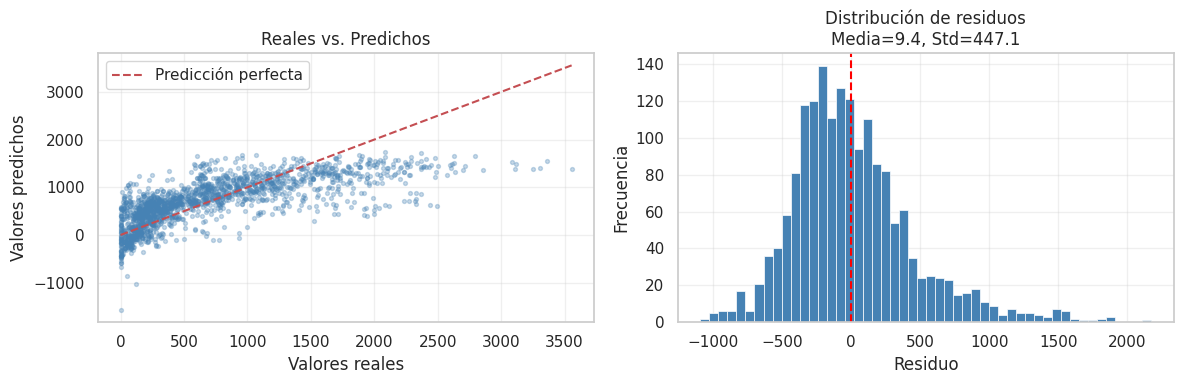

In [51]:
residuos = y_test - y_pred_fe

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Valores reales vs predichos
axes[0].scatter(y_test, y_pred_fe, alpha=0.3, s=8, color='steelblue')
lim = max(y_test.max(), y_pred_fe.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')
axes[0].set_title('Reales vs. Predichos')
axes[0].legend()

# 2. Histograma de residuos (debe ser aproximadamente normal)
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de residuos\nMedia={residuos.mean():.1f}, Std={residuos.std():.1f}')

plt.tight_layout()
plt.show()

Los residuos se concentran alrededor de cero, lo que sugiere que el modelo no presenta un sesgo global marcado. Sin embargo, la distribución no es completamente simétrica y se observan errores de mayor magnitud en algunos casos. Además, el modelo tiende a representar mejor los valores bajos e intermedios que los valores extremos, lo que puede indicar dificultades para capturar adecuadamente los casos de mayor demanda.

#### Actividad 3

1. Transforme la variable `Rented Bike Count` $\sqrt{x}$ usando y $\log(x)$. En ambos casos vuelva a entrenar el modelo de regresión lineal. ¿Se observaron algunos cambios?

**Nota** Genere una copia de los datos para resolver esta actividad.

## 10. Interpretación — Coeficientes del Modelo

En la regresión lineal, los coeficientes (después de escalar las variables) indican cuánto cambia la predicción por cada unidad de desviación estándar de cada característica. Las variables con coeficientes más grandes (en valor absoluto)
son las más influyentes.


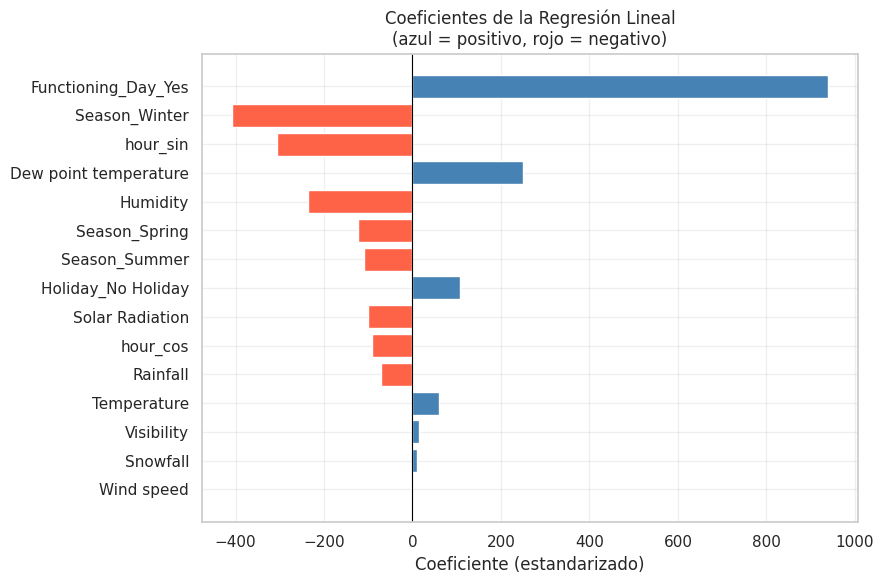

Top 5 variables con mayor impacto positivo en la demanda:
Functioning_Day_Yes      939.077512
Dew point temperature    249.853252
Holiday_No Holiday       107.701656
Temperature               60.224875
Visibility                14.043865

Top 5 variables con mayor impacto negativo:
Season_Winter   -407.956464
hour_sin        -306.327157
Humidity        -236.569057
Season_Spring   -123.864346
Season_Summer   -109.822411


In [52]:
coefs = pd.Series(lr_fe.coef_, index=X_train_fe.columns)
coefs_sorted = coefs.abs().sort_values(ascending=True)

colors = ['tomato' if v < 0 else 'steelblue' for v in coefs[coefs_sorted.index]]

plt.figure(figsize=(9, 6))
sns.set_theme(style='whitegrid') # Apply seaborn style here
bars = plt.barh(coefs_sorted.index, coefs[coefs_sorted.index], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (estandarizado)')
plt.title('Coeficientes de la Regresión Lineal\n(azul = positivo, rojo = negativo)')
plt.tight_layout()
plt.show()

print("Top 5 variables con mayor impacto positivo en la demanda:")
print(coefs.sort_values(ascending=False).head(5).to_string())
print("\nTop 5 variables con mayor impacto negativo:")
print(coefs.sort_values().head(5).to_string())

#### Actividad 4

Una de las principales limitantes del ejercicio es que se usa un modelo lineal, el cual puede ser bastante limitado para el problema de regresión planteado.

1. Usar la base de datos procesada para entrenar un modelo de árboles de decisión para regresión.

**Nota** Genere una copia de los datos para resolver esta actividad.

In [ ]:
## Completar con el código necesario.